# **Ｌｏａｎ Ｅｌｉｇｉｂｉｌｉｔｙ Ｐｒｅｄｉｃｔｉｏｎ | ＥＤＡ ＆ ＭＬ**

## **Data Processing Pipeline**
### **Analytical Platform**

### **Data Ingestion**

### **Initial Data Overview**

### **EDA**
* **Univariate Analysis & Visualization**
* **Bivariate Analysis & Visualization**
* **Multivariate Analysis & Visualization**
  
### **Machine Learning**
* **Classification Task / X_Encoded / Regression Task**
* **Classification Model Training and F1 Score Evaluation**
* **Train and Evaluate Regression Model 1 (Linear Regression)**
* **Train and Evaluate Regression Model 2 (Random Forest Regressor)**
* **Train and Evaluate Regression Model 3 (Gradient Boosting Regressor)**
* **Compare Regression Models and Identify the Best**
* **Best Regression Model Identification**

### **Summary**

## **Analytical Platform**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

## **Data Ingestion**

In [2]:
df = pd.read_csv('D:/PYTHON 2/ᗪᗩTᗩ/NOVEMBER/Loan Eligibility Prediction DataSet/Loan Eligibility Prediction.csv')
df.head()

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,569,Female,No,0,Graduate,No,2378,0.0,9,360,1,Urban,N
1,15,Male,Yes,2,Graduate,No,1299,1086.0,17,120,1,Urban,Y
2,95,Male,No,0,Not Graduate,No,3620,0.0,25,120,1,Semiurban,Y
3,134,Male,Yes,0,Graduate,Yes,3459,0.0,25,120,1,Semiurban,Y
4,556,Male,Yes,1,Graduate,No,5468,1032.0,26,360,1,Semiurban,Y


## **Initial Data Overview**

In [3]:
print("DataFrame Shape:", df.shape)
print("\nDataFrame Info:")
df.info()
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDescriptive Statistics for Numerical Columns:")
print(df.describe())

DataFrame Shape: (614, 13)

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         614 non-null    int64  
 1   Gender              614 non-null    object 
 2   Married             614 non-null    object 
 3   Dependents          614 non-null    int64  
 4   Education           614 non-null    object 
 5   Self_Employed       614 non-null    object 
 6   Applicant_Income    614 non-null    int64  
 7   Coapplicant_Income  614 non-null    float64
 8   Loan_Amount         614 non-null    int64  
 9   Loan_Amount_Term    614 non-null    int64  
 10  Credit_History      614 non-null    int64  
 11  Property_Area       614 non-null    object 
 12  Loan_Status         614 non-null    object 
dtypes: float64(1), int64(6), object(6)
memory usage: 62.5+ KB

Missing Values:
Customer_ID           0
Gender      

## **EDA**

### **Univariate Analysis & Visualization**

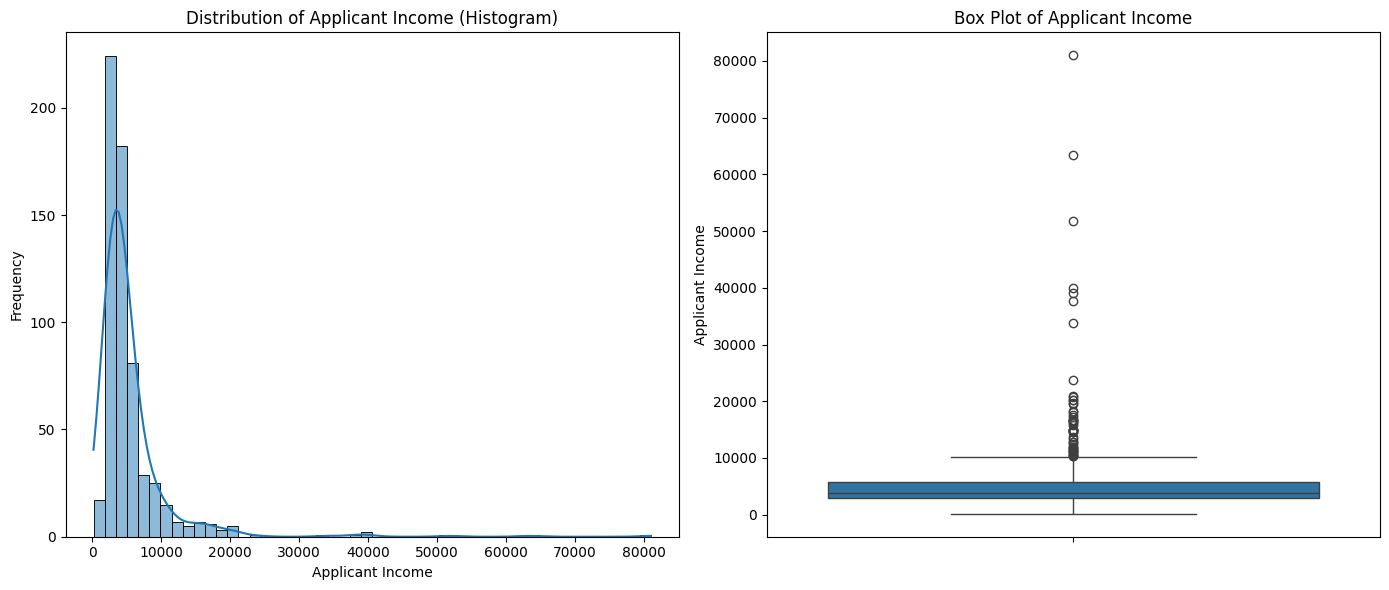

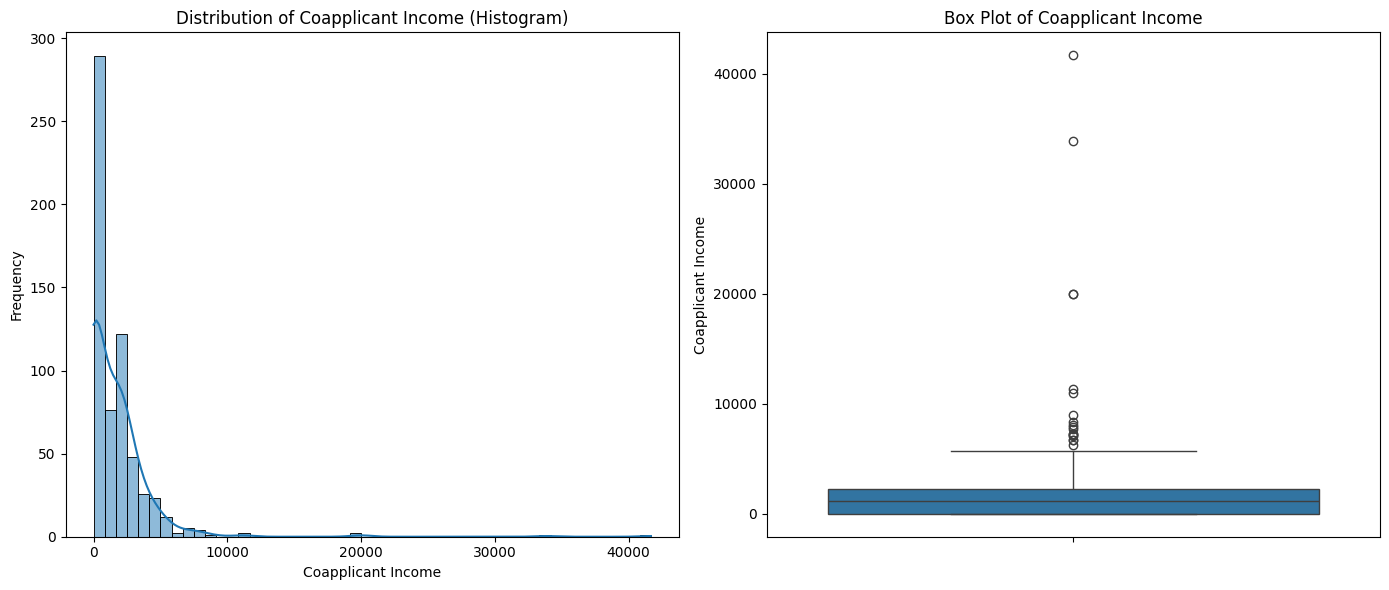

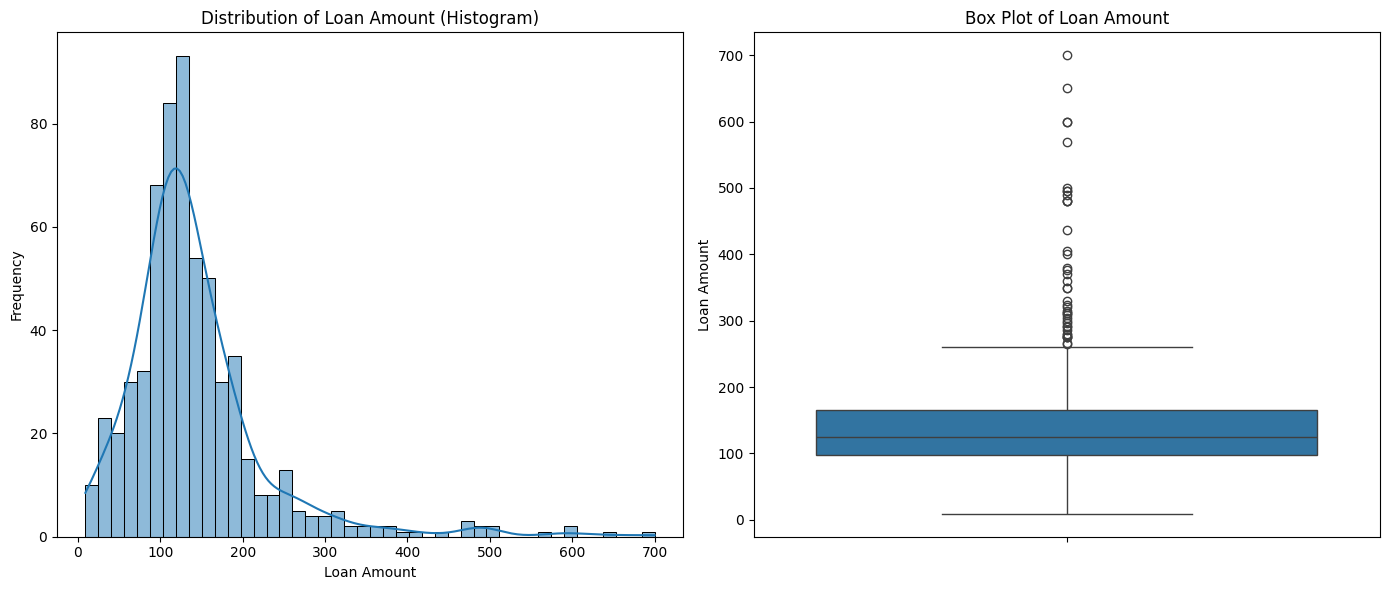

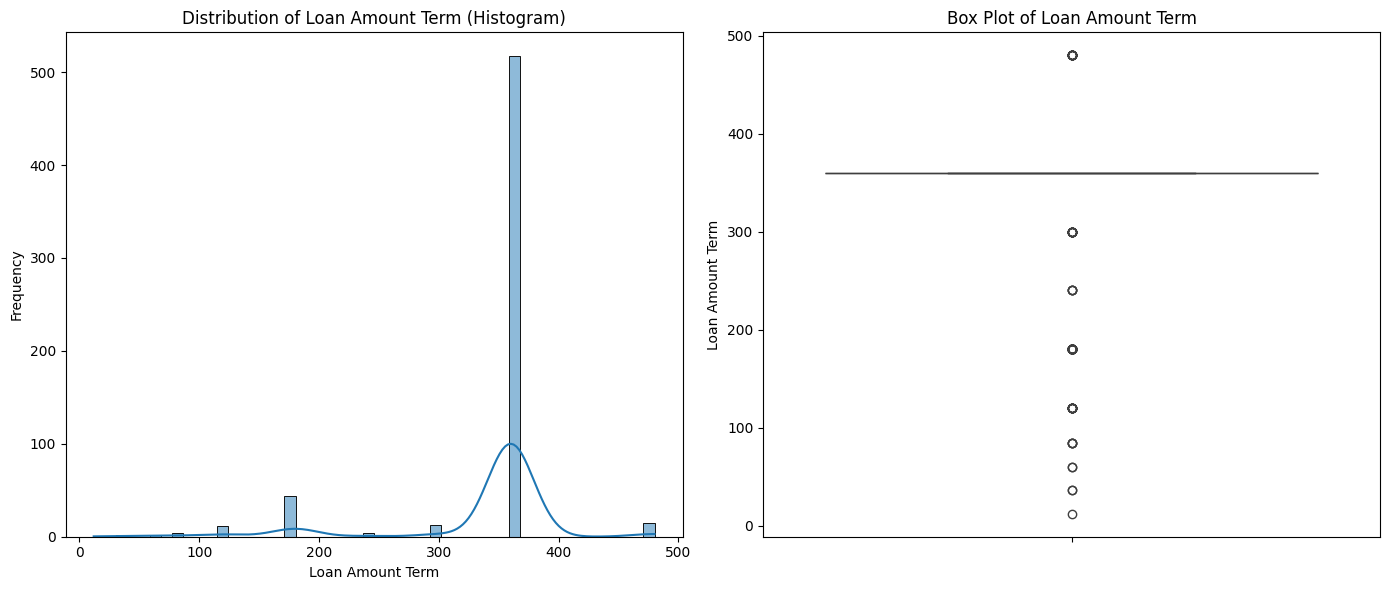

In [4]:
Numerical_Columns = ['Applicant_Income', 'Coapplicant_Income', 'Loan_Amount', 'Loan_Amount_Term']

for col in Numerical_Columns:
    plt.figure(figsize=(14, 6))

    
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col.replace("_", " ")} (Histogram)')
    plt.xlabel(col.replace("_", " "))
    plt.ylabel('Frequency')

    
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col.replace("_", " ")}')
    plt.ylabel(col.replace("_", " "))

    plt.tight_layout()
    plt.show()

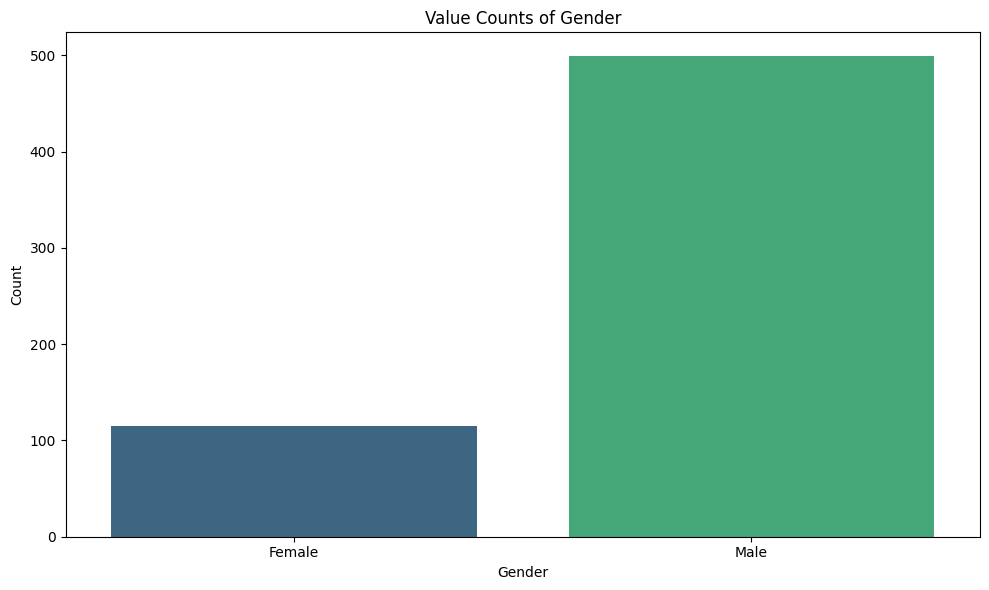

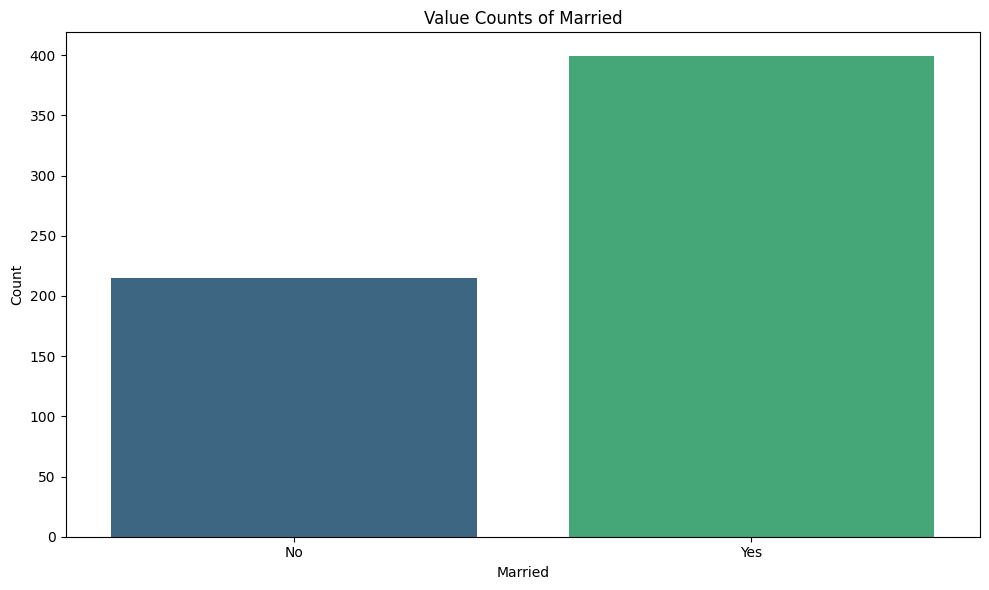

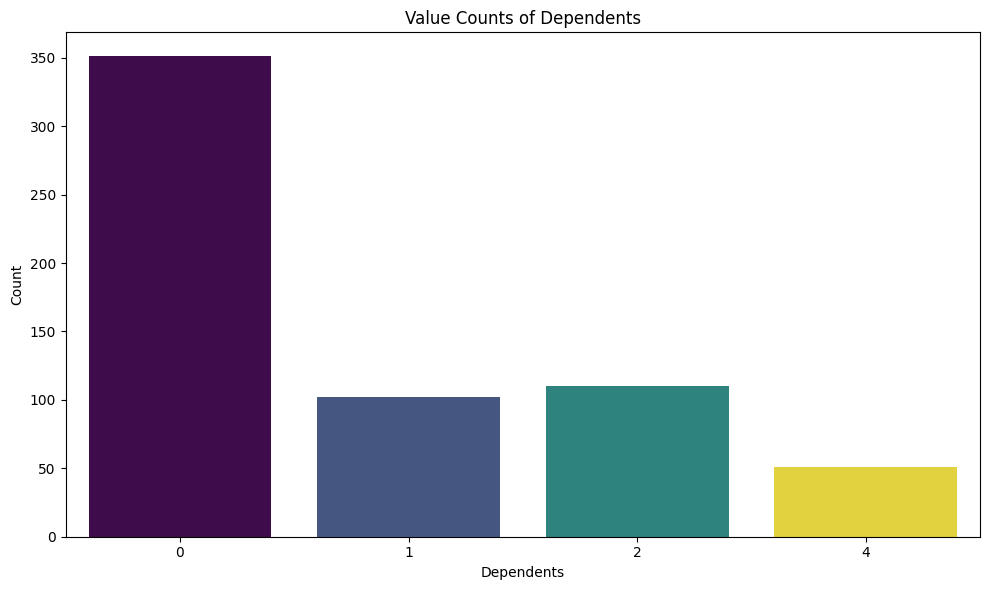

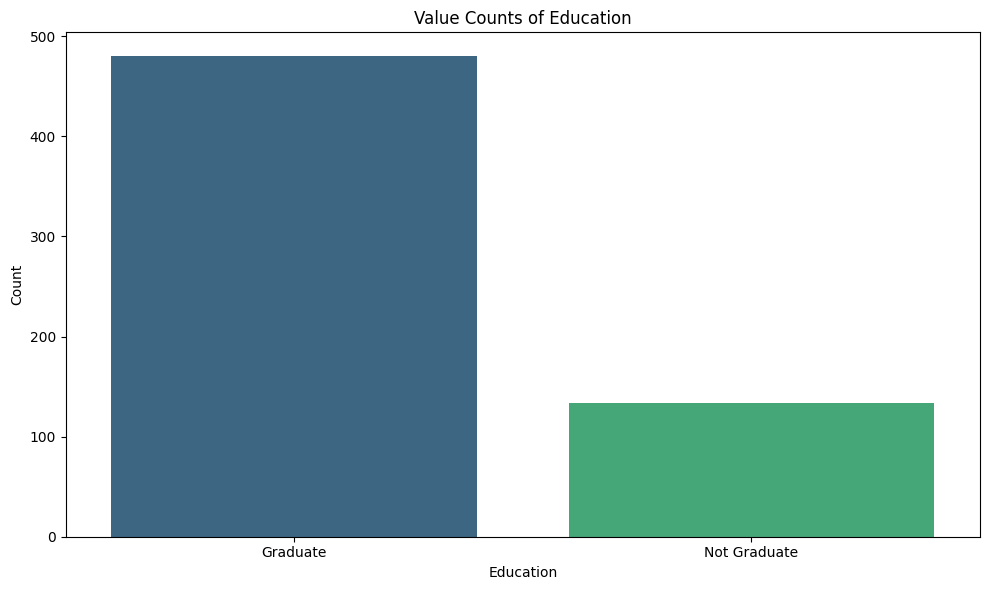

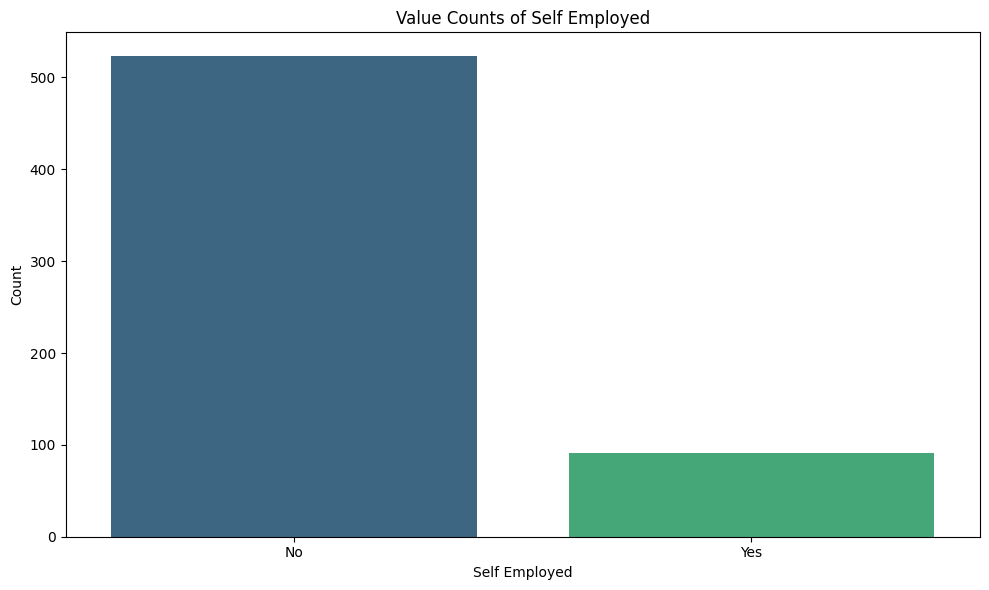

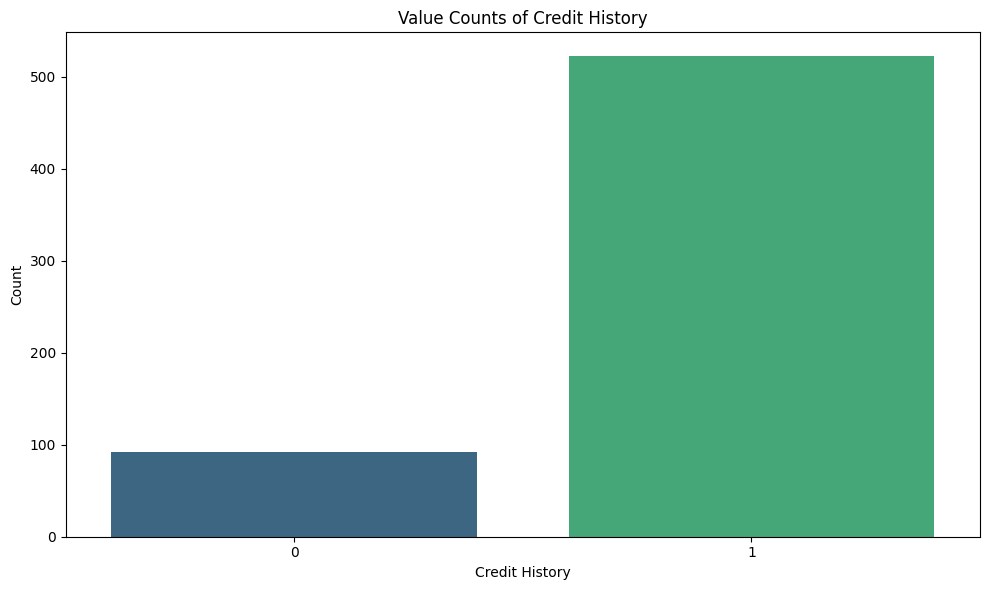

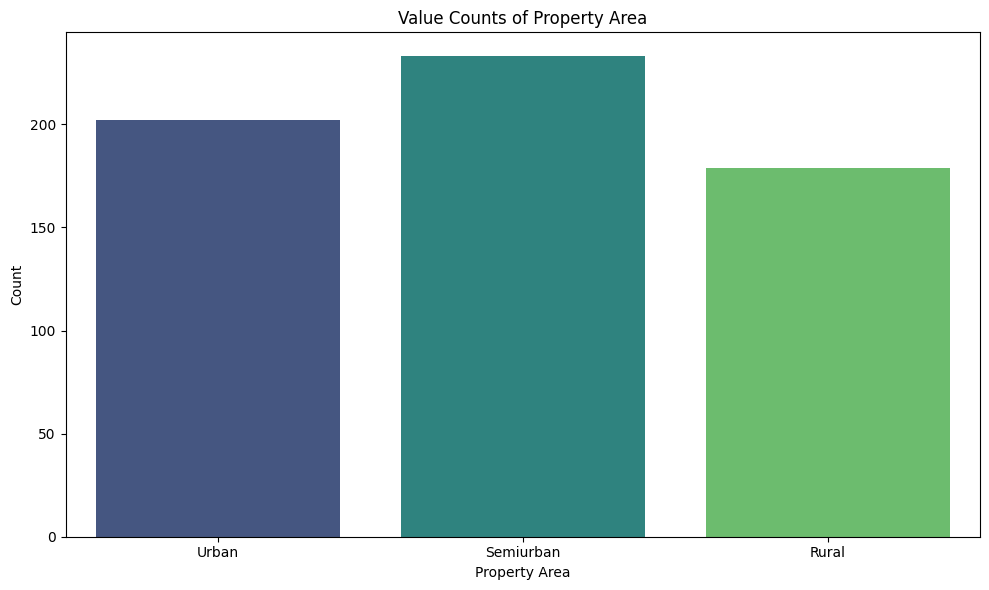

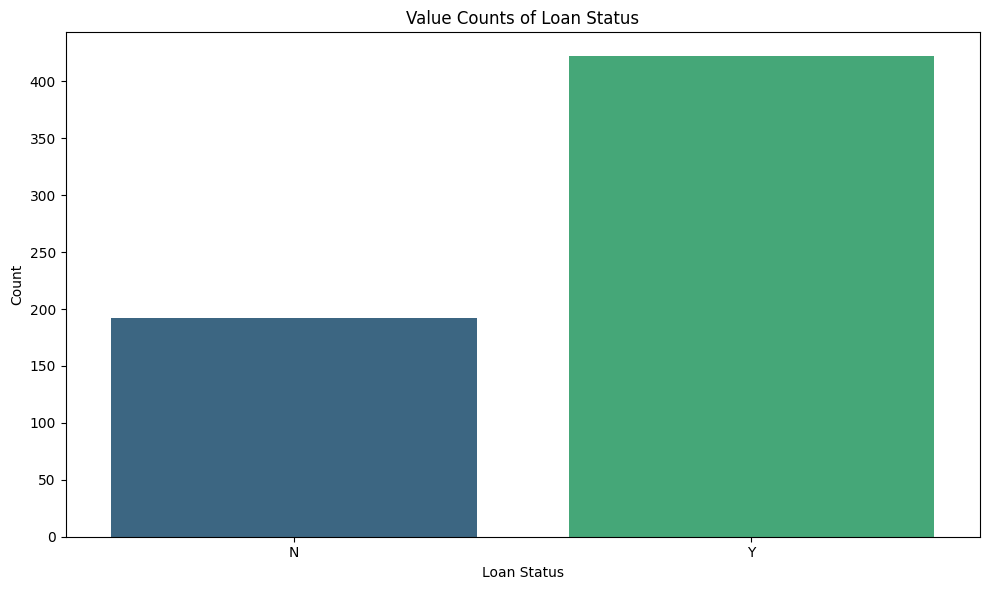

In [5]:
Categorical_Columns = ['Gender', 'Married', 'Dependents', 'Education',
                       'Self_Employed', 'Credit_History', 'Property_Area', 'Loan_Status']

for col in Categorical_Columns:
    plt.figure(figsize=(10, 6))
    
    sns.countplot(
        x=col,
        data=df,
        hue=col,            # required to use palette
        palette='viridis',
        legend=False        # hide legend
    )
    
    plt.title(f'Value Counts of {col.replace("_", " ")}')
    plt.xlabel(col.replace("_", " "))
    plt.ylabel('Count')
    
    if len(df[col].unique()) > 5:
        plt.xticks(rotation=45, ha='right')
        
    plt.tight_layout()
    plt.show()

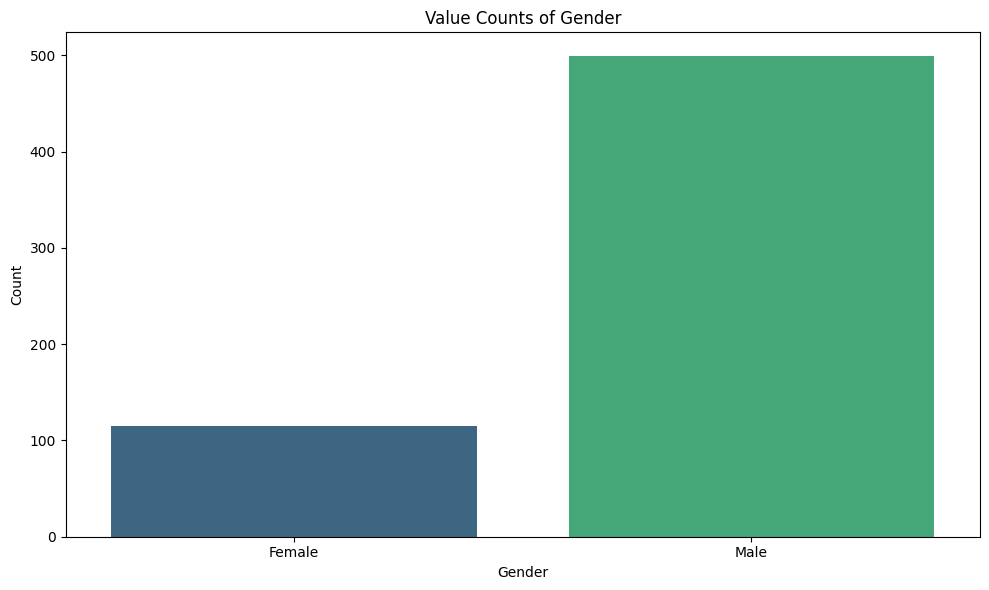

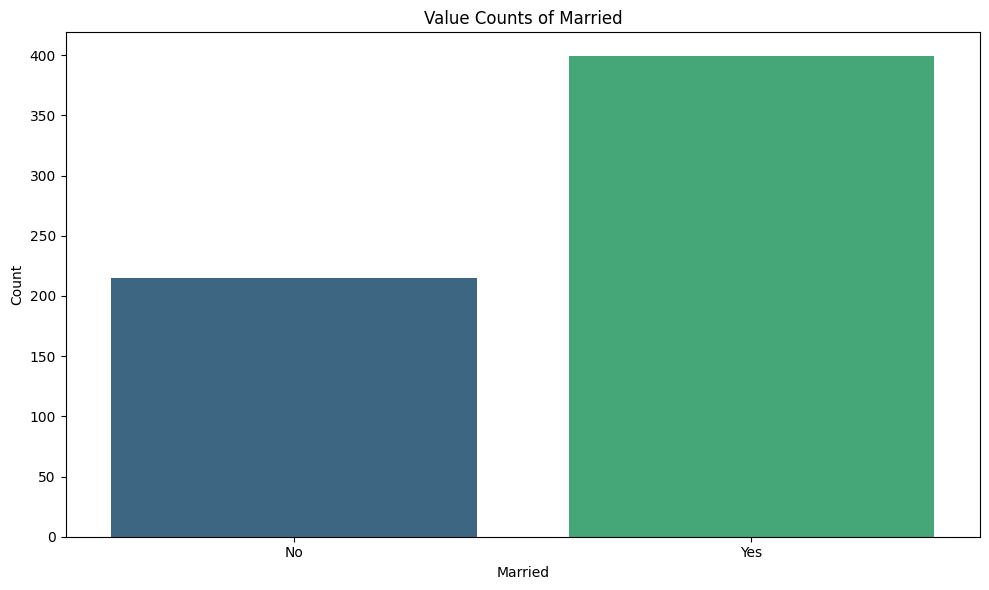

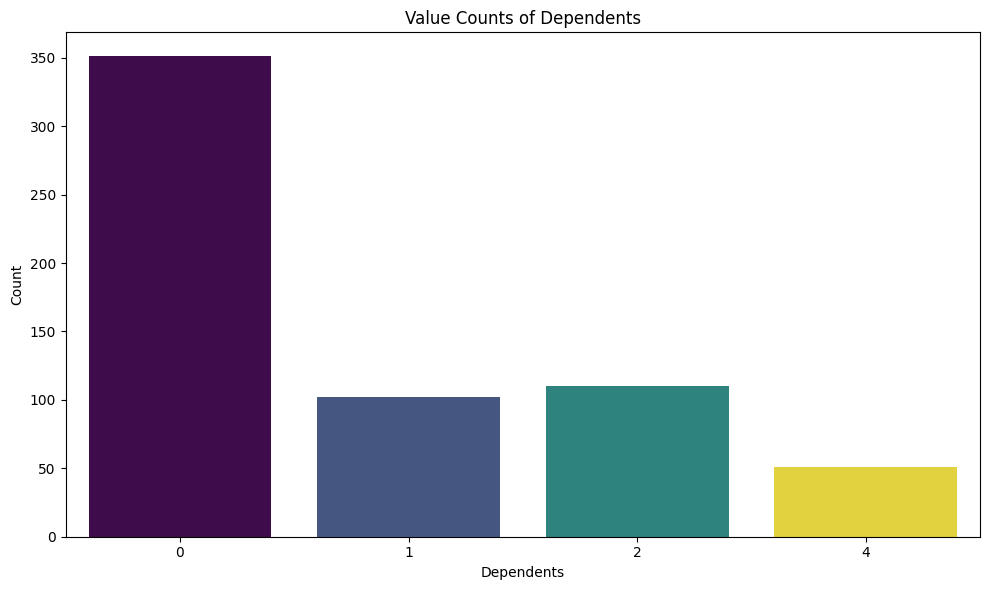

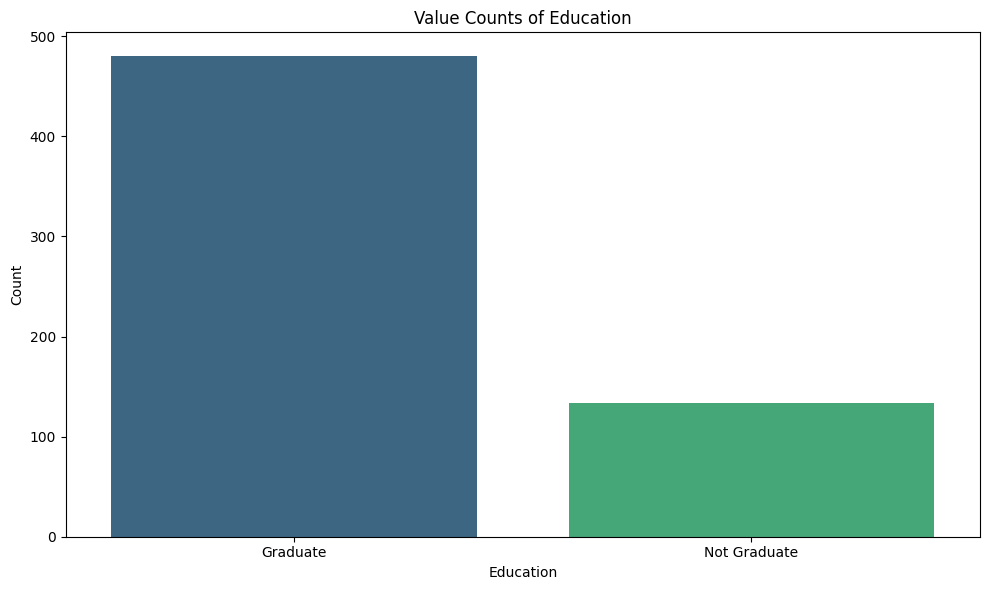

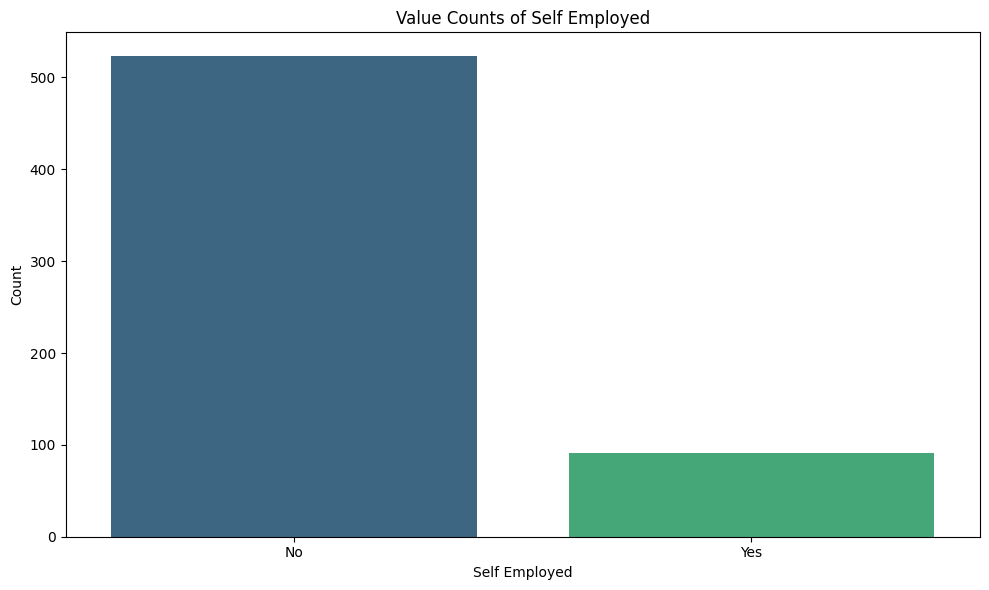

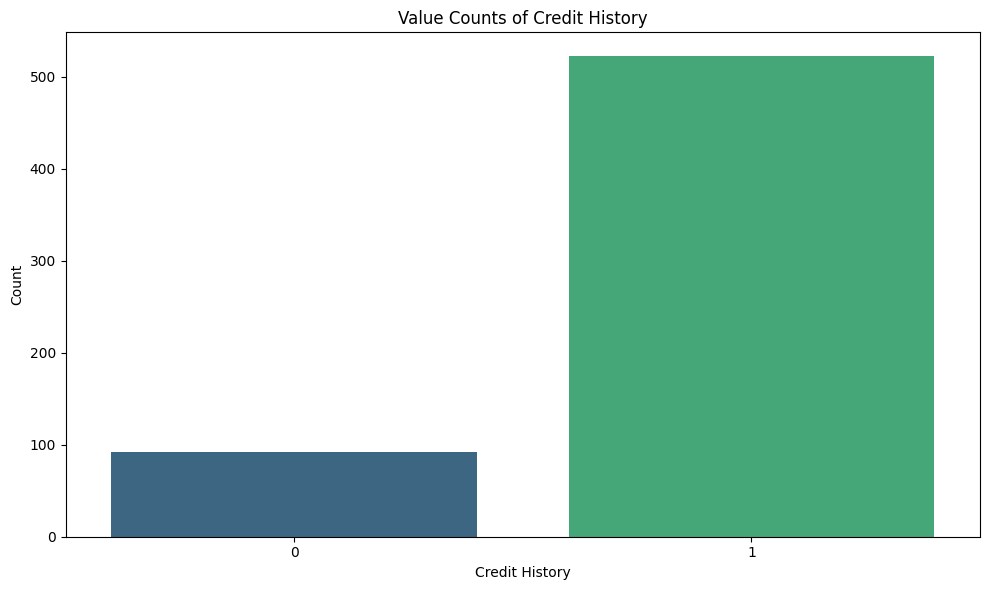

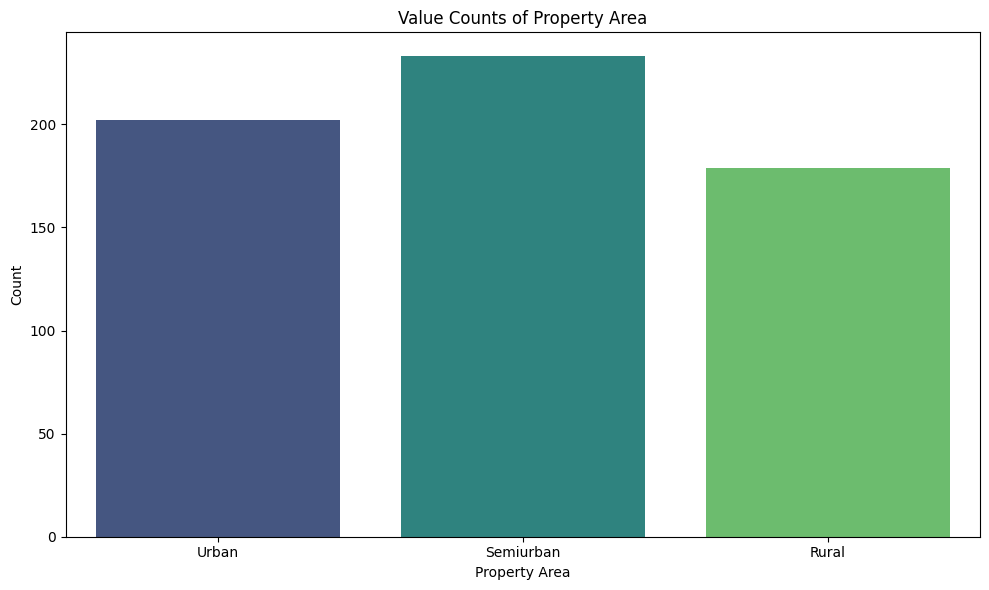

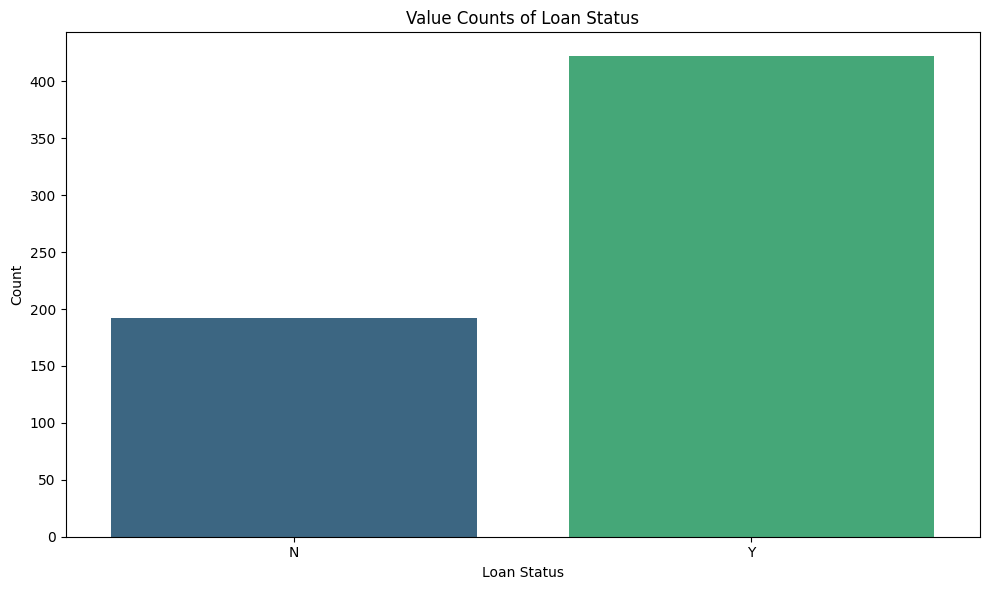

In [6]:
Categorical_Columns = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Credit_History', 'Property_Area', 'Loan_Status']

for col in Categorical_Columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=df[col], hue=df[col], palette='viridis', legend=False)
    plt.title(f'Value Counts of {col.replace("_", " ")}')
    plt.xlabel(col.replace("_", " "))
    plt.ylabel('Count')
    if len(df[col].unique()) > 5: 
        plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### **Bivariate Analysis & Visualization**

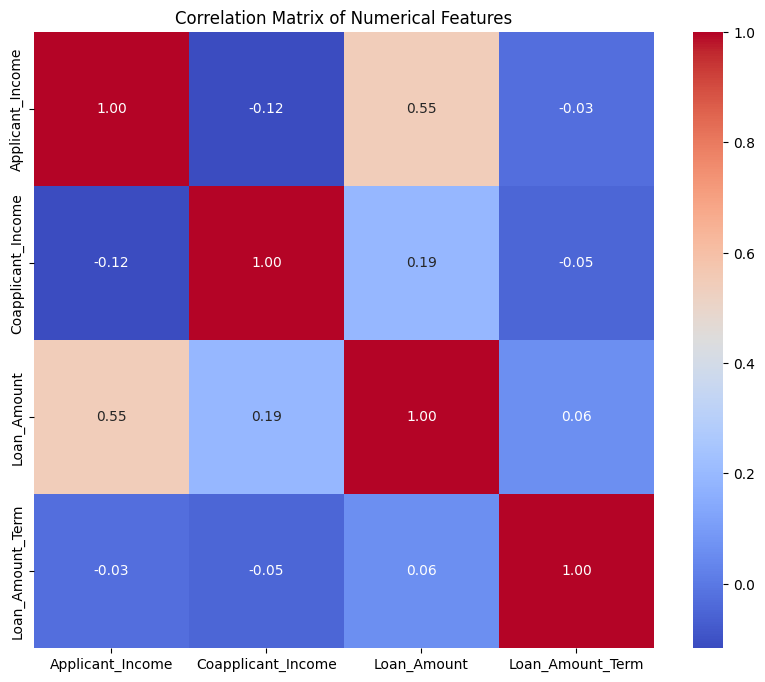

In [7]:
Numerical_Columns = ['Applicant_Income', 'Coapplicant_Income', 'Loan_Amount', 'Loan_Amount_Term']


Correlation_Matrix = df[Numerical_Columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(Correlation_Matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

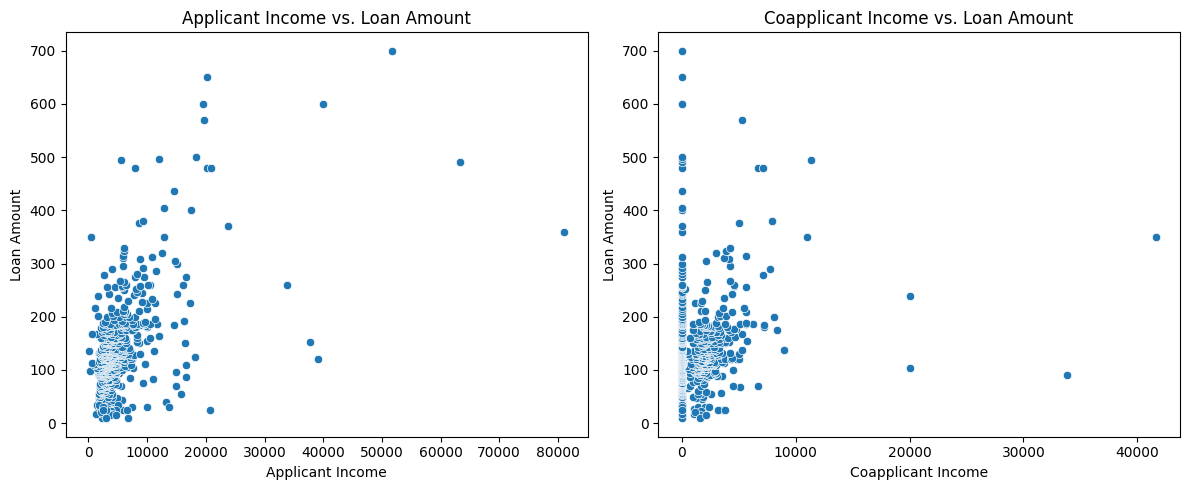

In [8]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=df['Applicant_Income'], y=df['Loan_Amount'])
plt.title('Applicant Income vs. Loan Amount')
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')

plt.subplot(1, 2, 2)
sns.scatterplot(x=df['Coapplicant_Income'], y=df['Loan_Amount'])
plt.title('Coapplicant Income vs. Loan Amount')
plt.xlabel('Coapplicant Income')
plt.ylabel('Loan Amount')

plt.tight_layout()
plt.show()

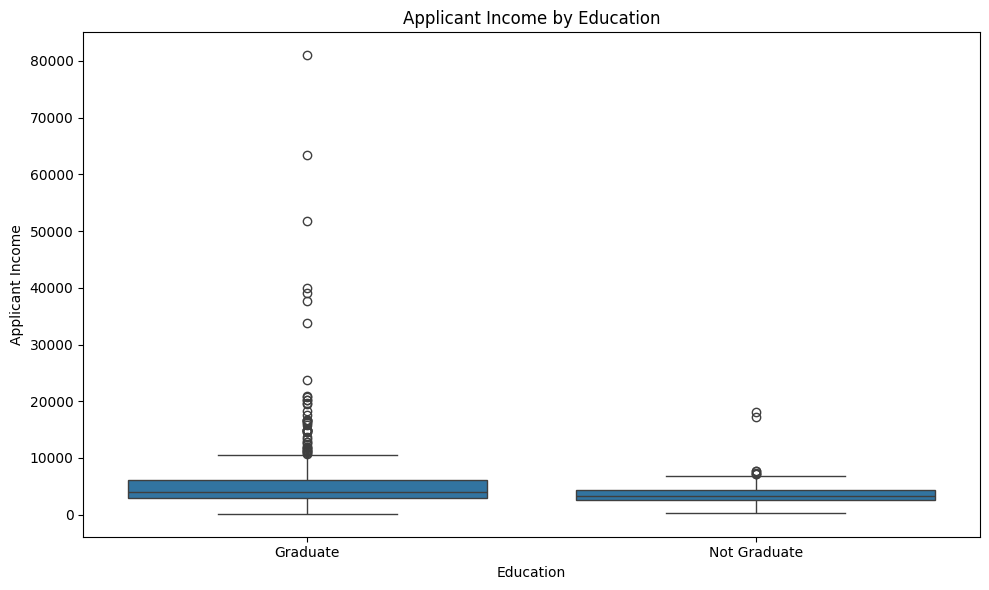

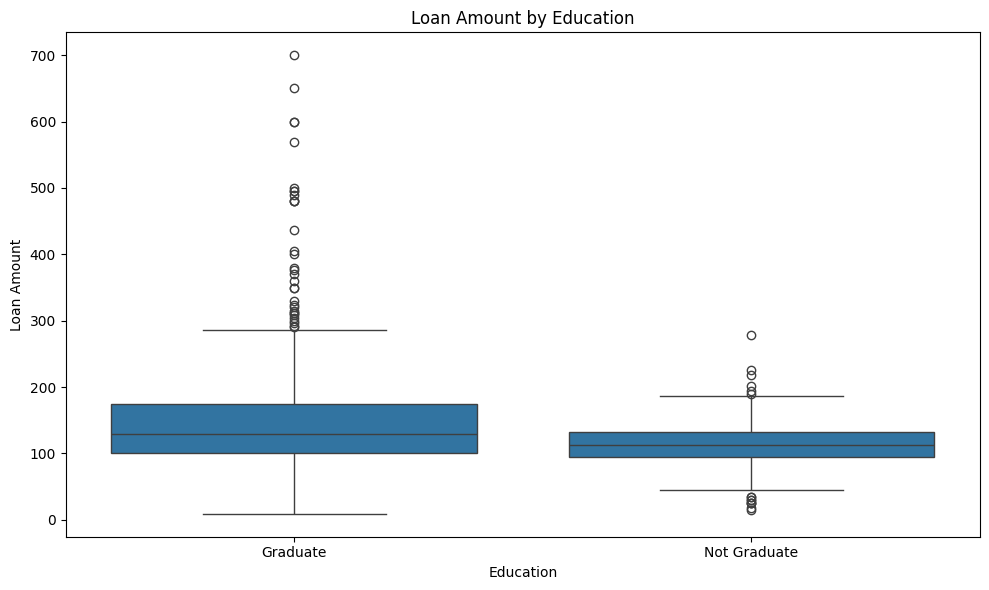

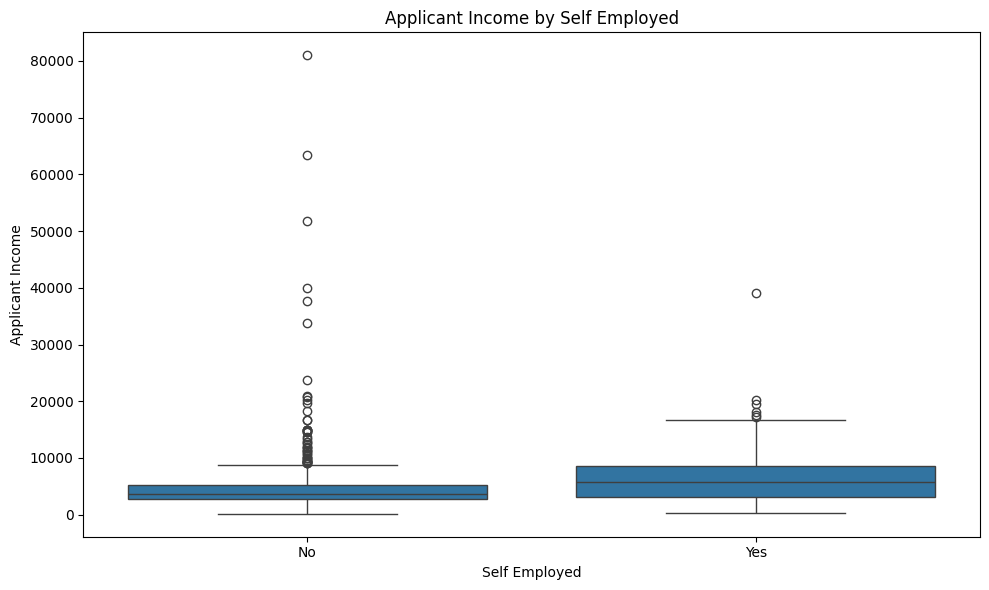

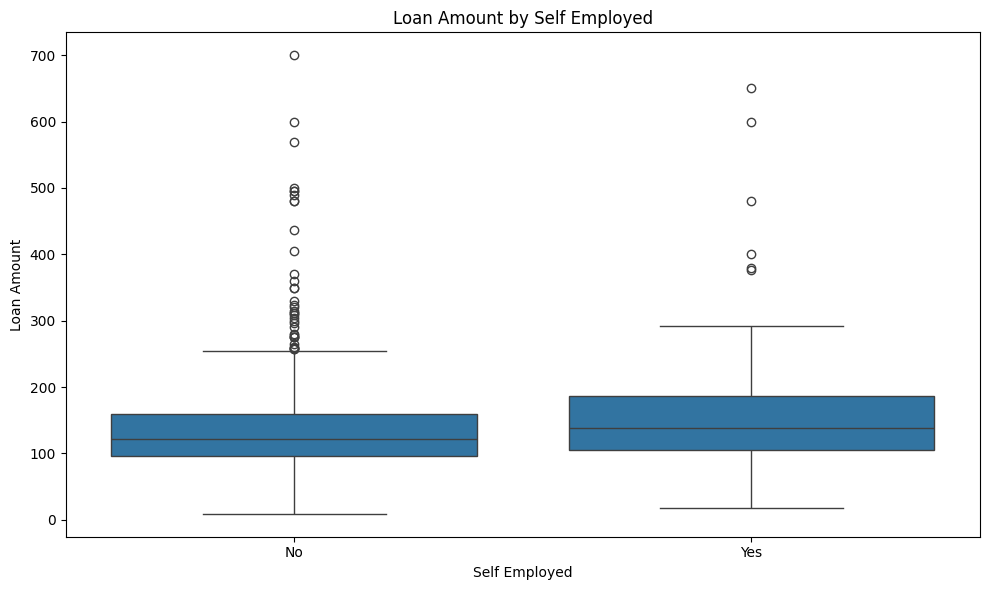

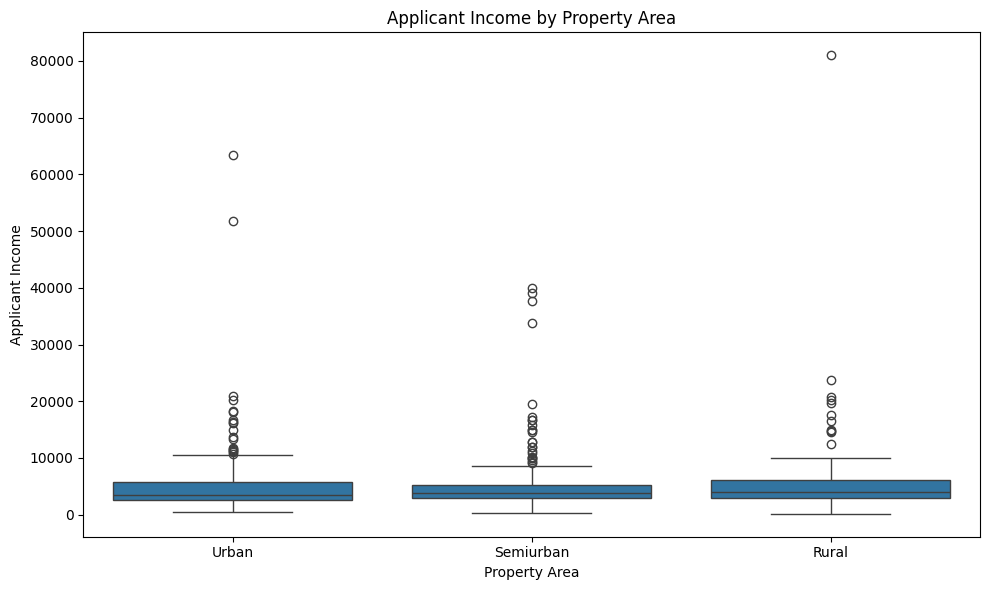

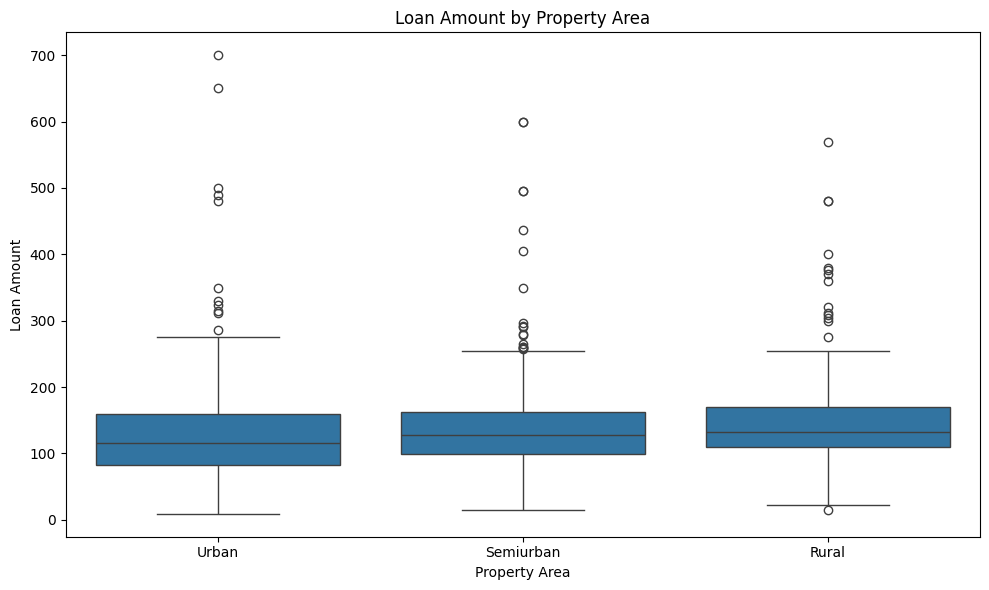

In [9]:
Categorical_Num_Pairs = [
    ('Education', 'Applicant_Income'),
    ('Education', 'Loan_Amount'),
    ('Self_Employed', 'Applicant_Income'),
    ('Self_Employed', 'Loan_Amount'),
    ('Property_Area', 'Applicant_Income'),
    ('Property_Area', 'Loan_Amount')
]

for cat_col, num_col in Categorical_Num_Pairs:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df[cat_col], y=df[num_col])
    plt.title(f'{num_col.replace("_", " ")} by {cat_col.replace("_", " ")}')
    plt.xlabel(cat_col.replace("_", " "))
    plt.ylabel(num_col.replace("_", " "))
    plt.tight_layout()
    plt.show()

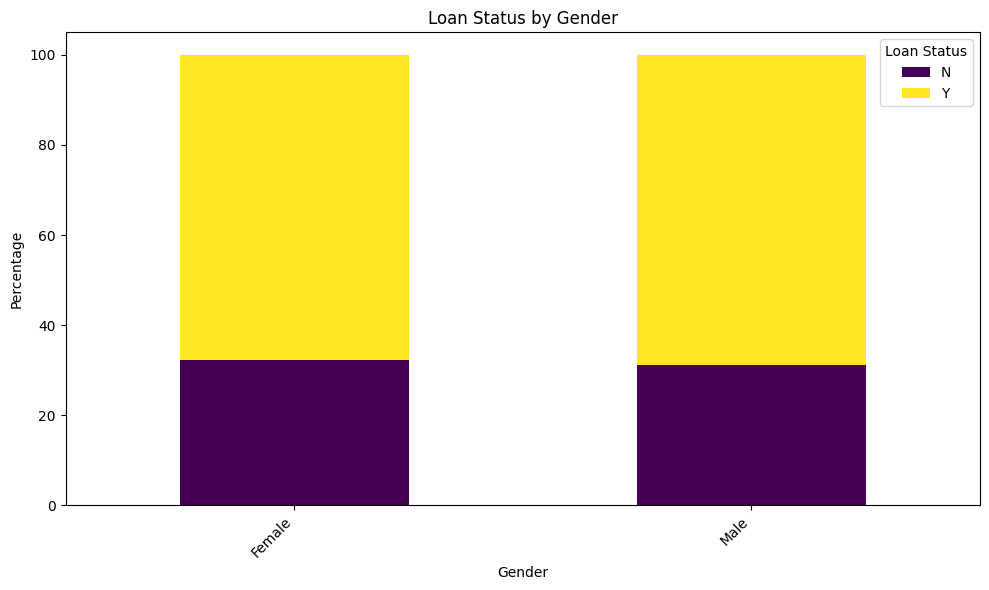

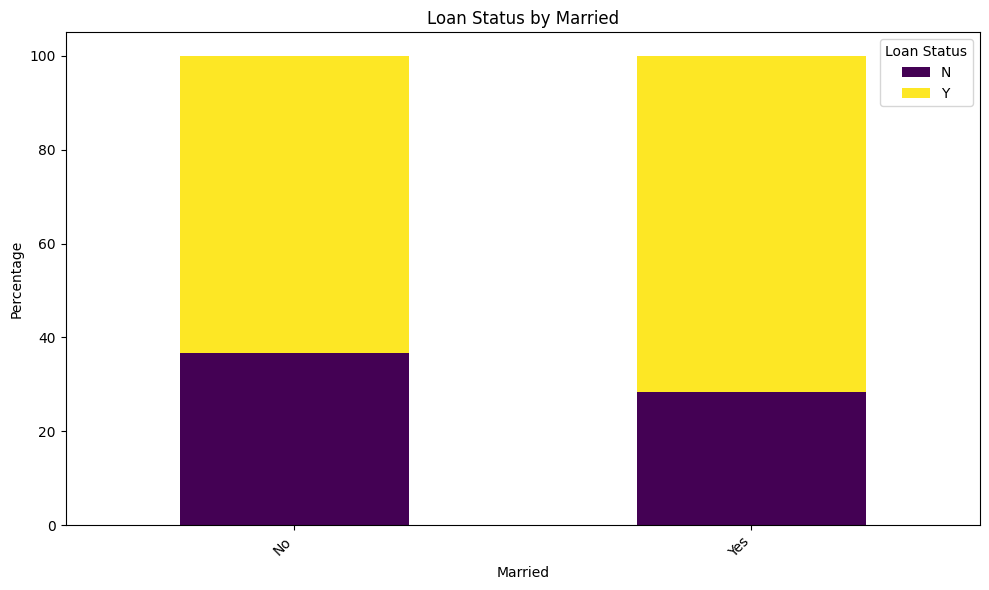

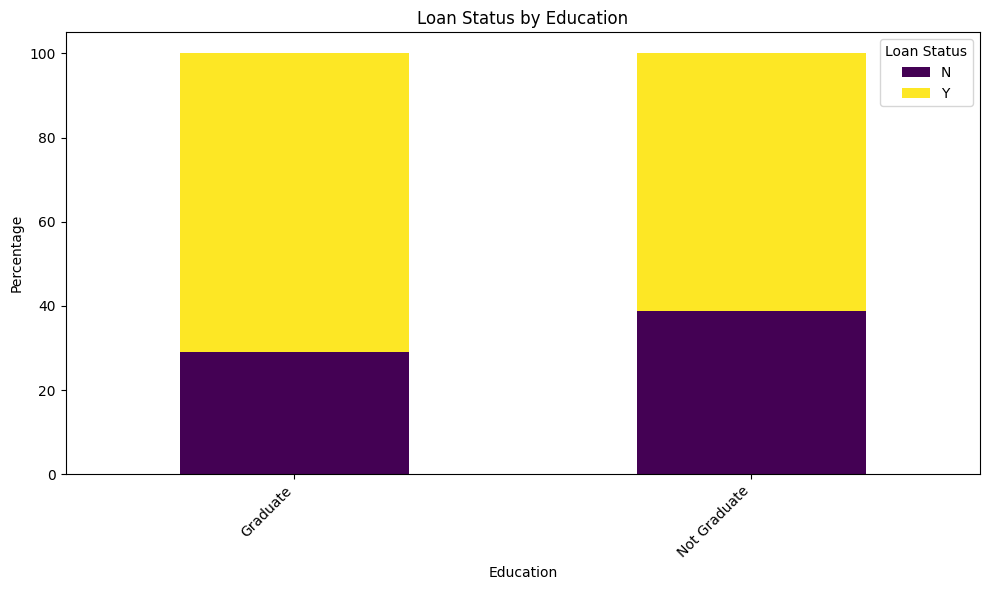

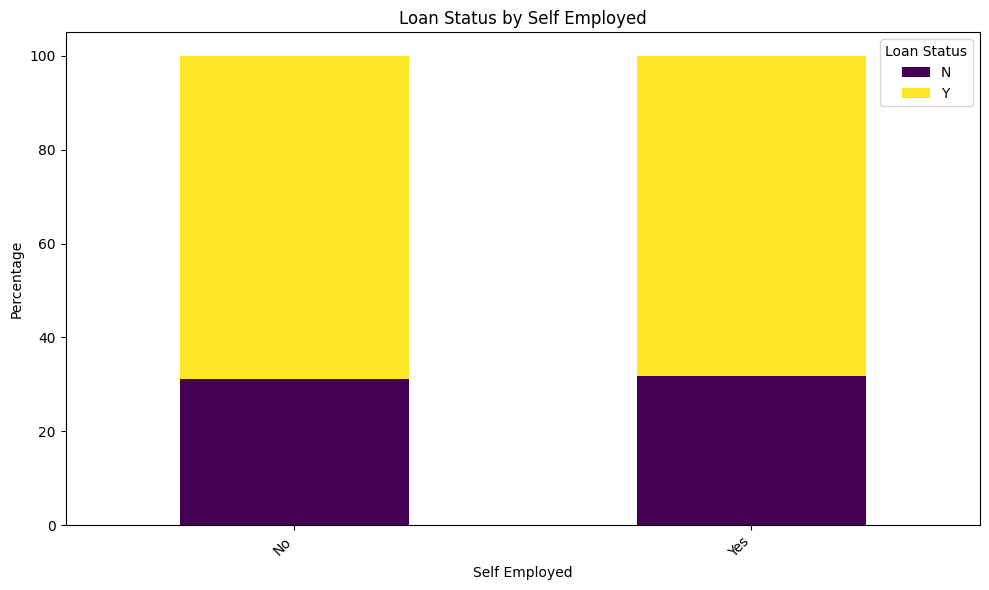

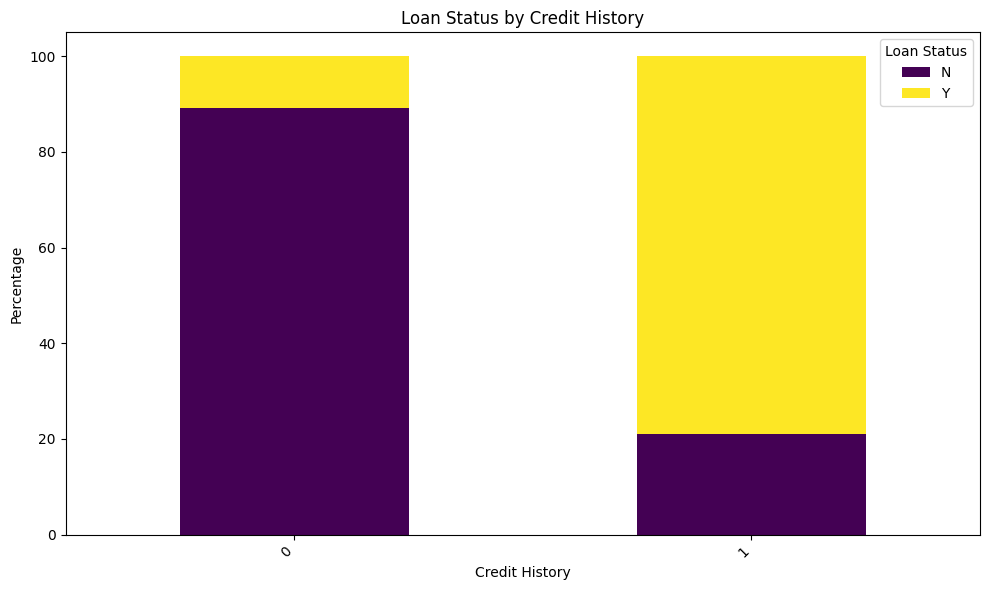

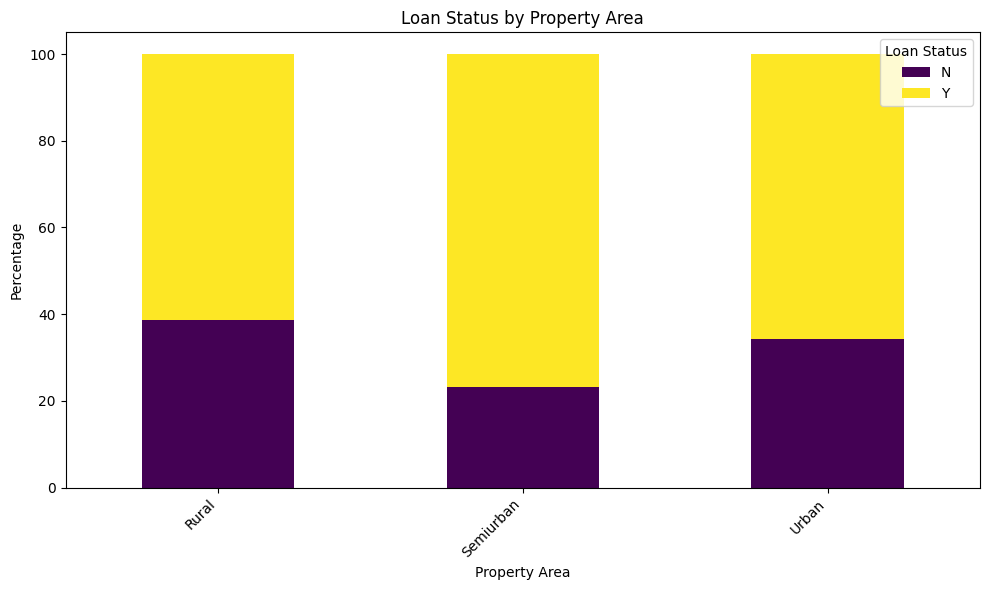

In [10]:
Categorical_columns_For_Loan_Status = [
    'Gender', 'Married', 'Education', 'Self_Employed', 'Credit_History', 'Property_Area'
]

for col in Categorical_columns_For_Loan_Status:
    
    ct = pd.crosstab(df[col], df['Loan_Status'], normalize='index') * 100

    plt.figure(figsize=(10, 6))
    ct.plot(kind='bar', stacked=True, colormap='viridis', ax=plt.gca())
    
    plt.title(f'Loan Status by {col.replace("_", " ")}')
    plt.xlabel(col.replace("_", " "))
    plt.ylabel('Percentage')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Loan Status')
    plt.tight_layout()
    plt.show()

### **Multivariate Analysis & Visualization**

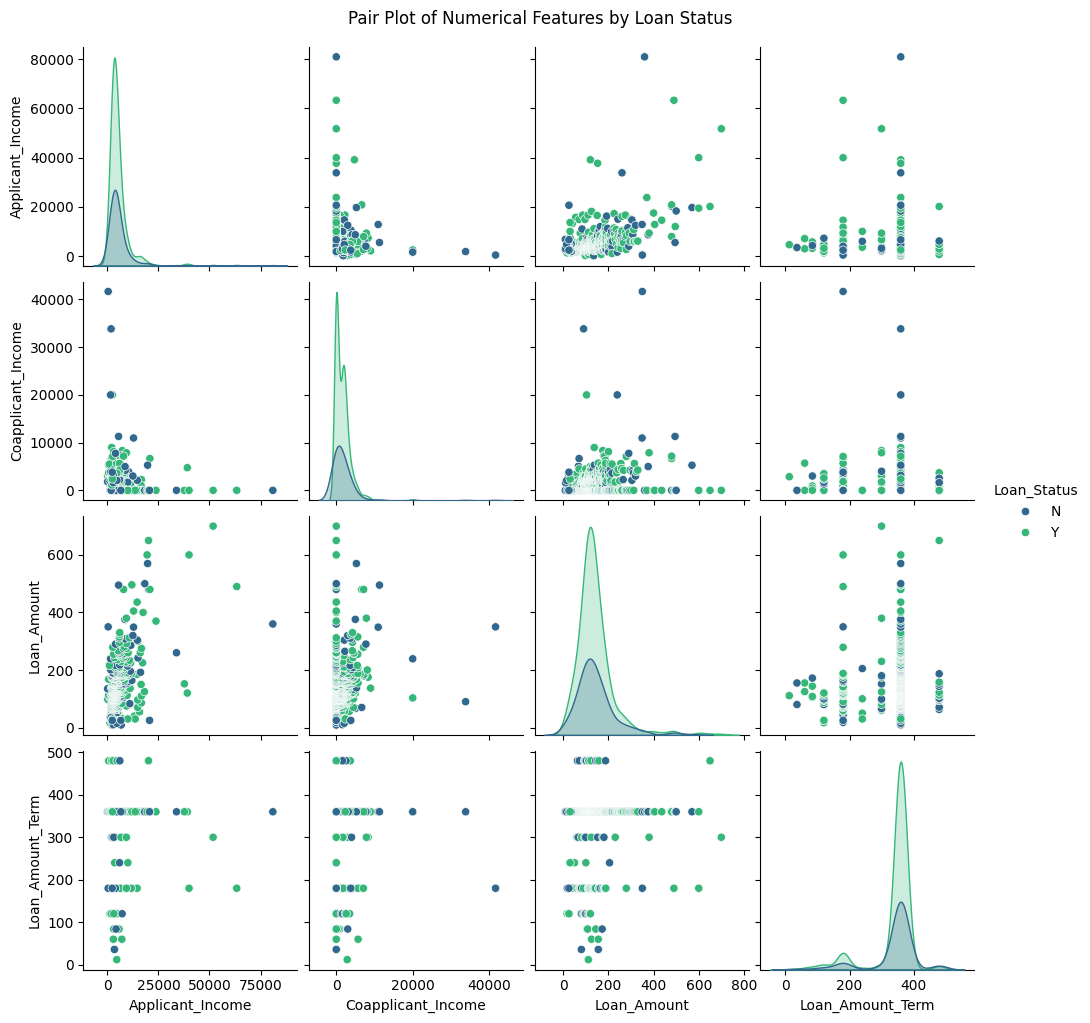

In [11]:
Numerical_Columns_For_Pairplot = ['Applicant_Income', 'Coapplicant_Income', 
                                  'Loan_Amount', 'Loan_Amount_Term']

sns.pairplot(df[Numerical_Columns_For_Pairplot + ['Loan_Status']], 
             hue='Loan_Status', palette='viridis')

plt.suptitle('Pair Plot of Numerical Features by Loan Status', y=1.02)
plt.show()

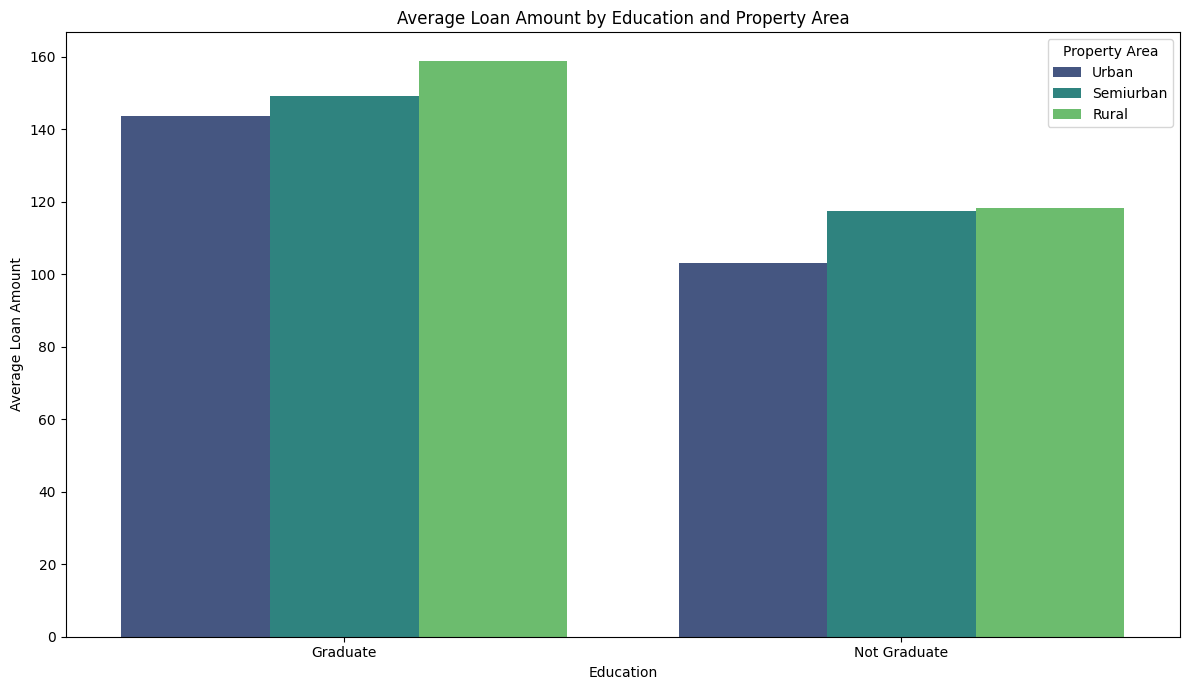

In [12]:
plt.figure(figsize=(12, 7))
sns.barplot(
    x='Education',
    y='Loan_Amount',
    hue='Property_Area',
    data=df,
    palette='viridis',
    errorbar=None       
)
plt.title('Average Loan Amount by Education and Property Area')
plt.xlabel('Education')
plt.ylabel('Average Loan Amount')
plt.legend(title='Property Area')
plt.tight_layout()
plt.show()

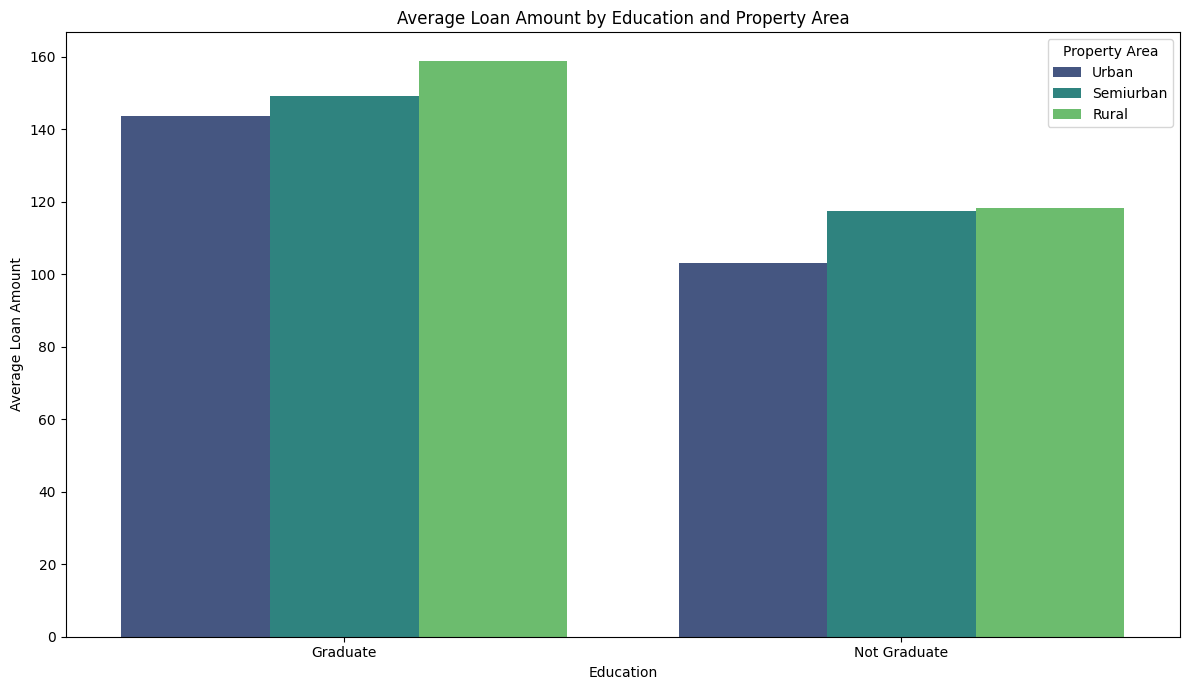

In [13]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Education', y='Loan_Amount', hue='Property_Area', data=df, palette='viridis', errorbar=None)
plt.title('Average Loan Amount by Education and Property Area')
plt.xlabel('Education')
plt.ylabel('Average Loan Amount')
plt.legend(title='Property Area')
plt.tight_layout()
plt.show()

## **Machine Learning**

### **Classification Task / X_Encoded / Regression Task**

In [14]:
df_processed = df.copy()
df_processed = df_processed.drop('Customer_ID', axis=1)

categorical_cols_for_ohe = [col for col in df_processed.select_dtypes(include='object').columns if col != 'Loan_Status']


X_encoded = pd.get_dummies(df_processed, columns=categorical_cols_for_ohe, drop_first=True, dtype=int)


le = LabelEncoder()
y_classification = le.fit_transform(X_encoded['Loan_Status'])


y_regression = X_encoded['Loan_Amount']


X_classification = X_encoded.drop(['Loan_Status', 'Loan_Amount'], axis=1)


X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_classification, y_classification, test_size=0.2, random_state=42, stratify=y_classification
)


X_regression = X_encoded.drop(['Loan_Status', 'Loan_Amount'], axis=1)


X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_regression, y_regression, test_size=0.2, random_state=42
)


print("Shapes for Classification Task:")
print(f"X_train_cls shape: {X_train_cls.shape}")
print(f"X_test_cls shape: {X_test_cls.shape}")
print(f"y_train_cls shape: {y_train_cls.shape}")
print(f"y_test_cls shape: {y_test_cls.shape}")

print("\nShapes for Regression Task:")
print(f"X_train_reg shape: {X_train_reg.shape}")
print(f"X_test_reg shape: {X_test_reg.shape}")
print(f"y_train_reg shape: {y_train_reg.shape}")
print(f"y_test_reg shape: {y_test_reg.shape}")


print("\nFirst 5 rows of X_encoded:")
print(X_encoded.head())
print("\nFirst 5 elements of y_classification:")
print(y_classification[:5])
print("\nFirst 5 elements of y_regression:")
print(y_regression[:5])

Shapes for Classification Task:
X_train_cls shape: (491, 11)
X_test_cls shape: (123, 11)
y_train_cls shape: (491,)
y_test_cls shape: (123,)

Shapes for Regression Task:
X_train_reg shape: (491, 11)
X_test_reg shape: (123, 11)
y_train_reg shape: (491,)
y_test_reg shape: (123,)

First 5 rows of X_encoded:
   Dependents  Applicant_Income  Coapplicant_Income  Loan_Amount  \
0           0              2378                 0.0            9   
1           2              1299              1086.0           17   
2           0              3620                 0.0           25   
3           0              3459                 0.0           25   
4           1              5468              1032.0           26   

   Loan_Amount_Term  Credit_History Loan_Status  Gender_Male  Married_Yes  \
0               360               1           N            0            0   
1               120               1           Y            1            1   
2               120               1           Y        

### **Classification Model Training and F1 Score Evaluation**


 Classification Model Evaluation 
Accuracy: 0.7642
Precision: 0.7979
Recall: 0.8824
F1 Score: 0.8380

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.50      0.57        38
           1       0.80      0.88      0.84        85

    accuracy                           0.76       123
   macro avg       0.73      0.69      0.70       123
weighted avg       0.75      0.76      0.75       123



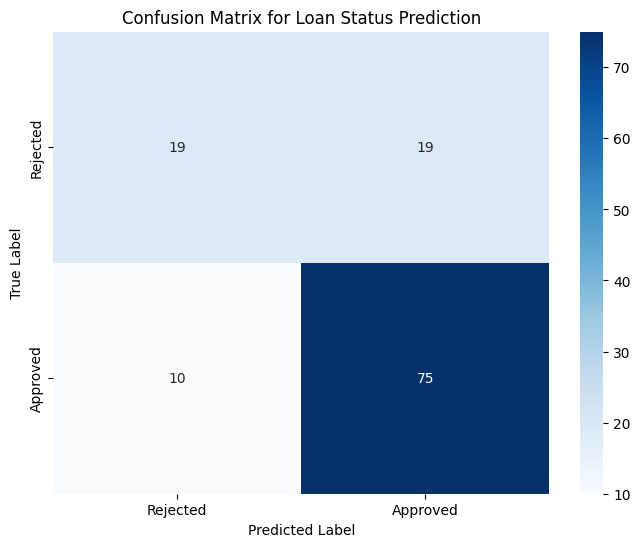

In [20]:
model_cls = RandomForestClassifier(random_state=42)
model_cls.fit(X_train_cls, y_train_cls)

y_pred_cls = model_cls.predict(X_test_cls)

print("\n Classification Model Evaluation ")
print(f"Accuracy: {accuracy_score(y_test_cls, y_pred_cls):.4f}")
print(f"Precision: {precision_score(y_test_cls, y_pred_cls):.4f}")
print(f"Recall: {recall_score(y_test_cls, y_pred_cls):.4f}")
print(f"F1 Score: {f1_score(y_test_cls, y_pred_cls):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_cls, y_pred_cls))

cm = confusion_matrix(y_test_cls, y_pred_cls)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Rejected', 'Approved'], yticklabels=['Rejected', 'Approved'])
plt.title('Confusion Matrix for Loan Status Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### **Train and Evaluate Regression Model 1 (Linear Regression)**

 Linear Regression Model Evaluation 
R-squared (R2): 0.4122
Mean Absolute Error (MAE): 44.6467
Mean Squared Error (MSE): 5456.8817
Root Mean Squared Error (RMSE): 73.8707


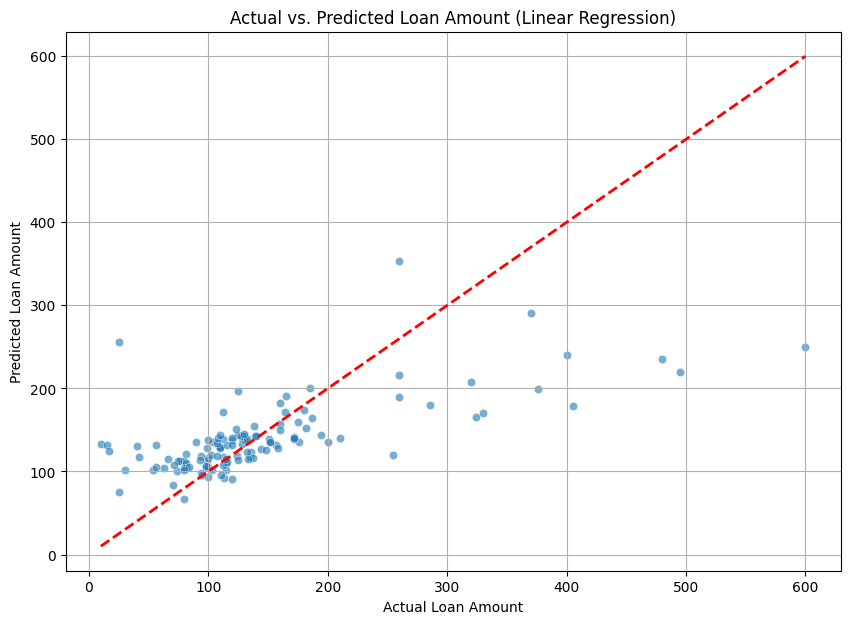

In [21]:
model_reg = LinearRegression()

model_reg.fit(X_train_reg, y_train_reg)


y_pred_reg = model_reg.predict(X_test_reg)


mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print(" Linear Regression Model Evaluation ")
print(f"R-squared (R2): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")


plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test_reg, y=y_pred_reg, alpha=0.6)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel('Actual Loan Amount')
plt.ylabel('Predicted Loan Amount')
plt.title('Actual vs. Predicted Loan Amount (Linear Regression)')
plt.grid(True)
plt.show()

### **Train and Evaluate Regression Model 2 (Random Forest Regressor)**

 Random Forest Regressor Model Evaluation 
R-squared (R2): 0.3404
Mean Absolute Error (MAE): 44.7063
Mean Squared Error (MSE): 6123.2975
Root Mean Squared Error (RMSE): 78.2515


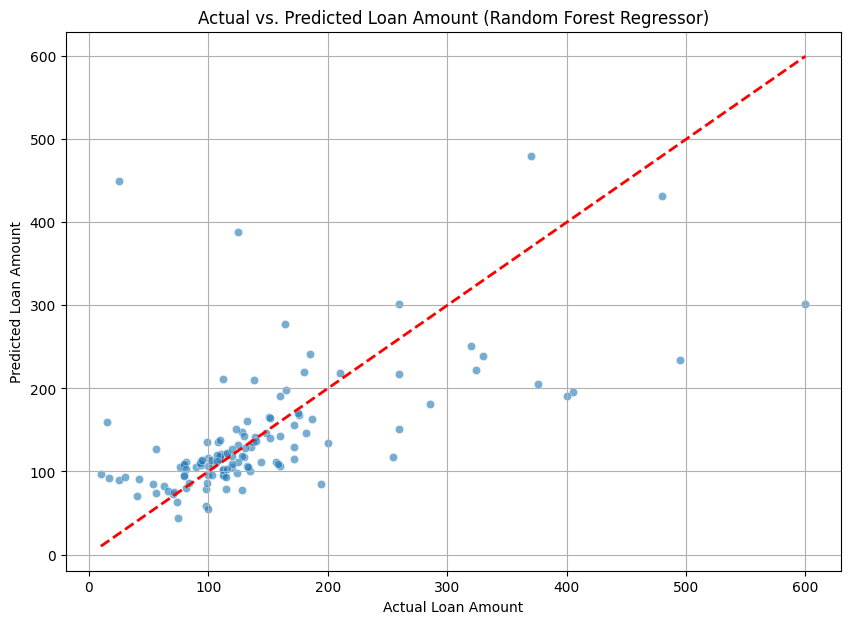

In [22]:
model_rfr = RandomForestRegressor(random_state=42)


model_rfr.fit(X_train_reg, y_train_reg)


y_pred_rfr = model_rfr.predict(X_test_reg)


mae_rfr = mean_absolute_error(y_test_reg, y_pred_rfr)
mse_rfr = mean_squared_error(y_test_reg, y_pred_rfr)
rmse_rfr = np.sqrt(mse_rfr)
r2_rfr = r2_score(y_test_reg, y_pred_rfr)

print(" Random Forest Regressor Model Evaluation ")
print(f"R-squared (R2): {r2_rfr:.4f}")
print(f"Mean Absolute Error (MAE): {mae_rfr:.4f}")
print(f"Mean Squared Error (MSE): {mse_rfr:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rfr:.4f}")


plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test_reg, y=y_pred_rfr, alpha=0.6)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel('Actual Loan Amount')
plt.ylabel('Predicted Loan Amount')
plt.title('Actual vs. Predicted Loan Amount (Random Forest Regressor)')
plt.grid(True)
plt.show()

### **Train and Evaluate Regression Model 3 (Gradient Boosting Regressor)**

 Gradient Boosting Regressor Model Evaluation 
R-squared (R2): 0.2092
Mean Absolute Error (MAE): 46.2045
Mean Squared Error (MSE): 7341.2738
Root Mean Squared Error (RMSE): 85.6812


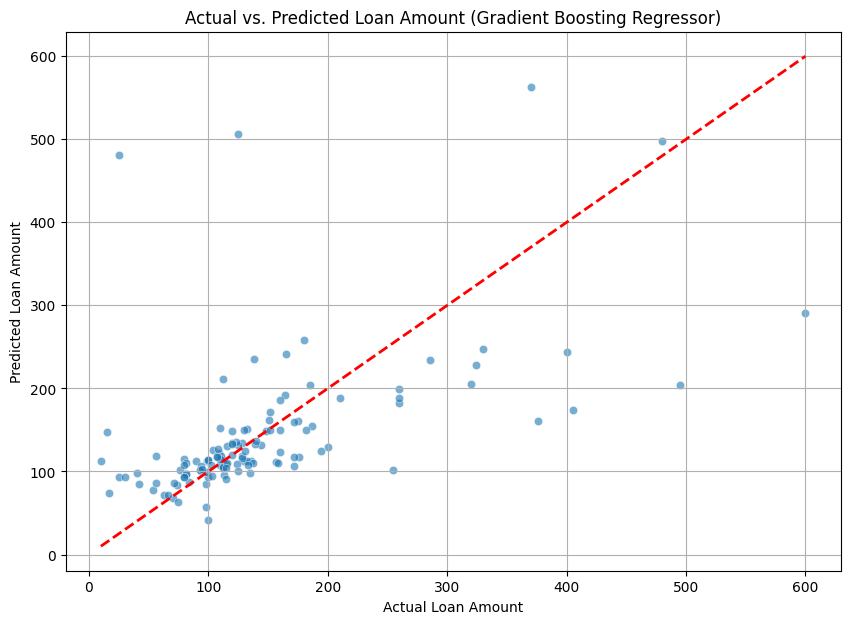

In [23]:
model_gbr = GradientBoostingRegressor(random_state=42)


model_gbr.fit(X_train_reg, y_train_reg)


y_pred_gbr = model_gbr.predict(X_test_reg)


mae_gbr = mean_absolute_error(y_test_reg, y_pred_gbr)
mse_gbr = mean_squared_error(y_test_reg, y_pred_gbr)
rmse_gbr = np.sqrt(mse_gbr)
r2_gbr = r2_score(y_test_reg, y_pred_gbr)

print(" Gradient Boosting Regressor Model Evaluation ")
print(f"R-squared (R2): {r2_gbr:.4f}")
print(f"Mean Absolute Error (MAE): {mae_gbr:.4f}")
print(f"Mean Squared Error (MSE): {mse_gbr:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_gbr:.4f}")


plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test_reg, y=y_pred_gbr, alpha=0.6)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel('Actual Loan Amount')
plt.ylabel('Predicted Loan Amount')
plt.title('Actual vs. Predicted Loan Amount (Gradient Boosting Regressor)')
plt.grid(True)
plt.show()

### **Compare Regression Models and Identify the Best**

In [19]:
metrics_data = {
    'Model': ['Linear Regression', 'Random Forest Regressor', 'Gradient Boosting Regressor'],
    'R-squared': [r2, r2_rfr, r2_gbr],
    'MAE': [mae, mae_rfr, mae_gbr],
    'MSE': [mse, mse_rfr, mse_gbr],
    'RMSE': [rmse, rmse_rfr, rmse_gbr]
}


comparison_df = pd.DataFrame(metrics_data)

print("Regression Model Performance Comparison:")
print(comparison_df.round(4))

Regression Model Performance Comparison:
                         Model  R-squared      MAE        MSE     RMSE
0            Linear Regression     0.4122  44.6467  5456.8817  73.8707
1      Random Forest Regressor     0.3404  44.7063  6123.2975  78.2515
2  Gradient Boosting Regressor     0.2092  46.2045  7341.2738  85.6812


### **Best Regression Model Identification**

Based on the "Regression Model Performance Comparison" table:

-   **Linear Regression** has the highest R-squared value (0.4122).
-   **Linear Regression** also has the lowest Mean Absolute Error (MAE) (44.6467).
-   **Linear Regression** has the lowest Mean Squared Error (MSE) (5456.8817).
-   **Linear Regression** has the lowest Root Mean Squared Error (RMSE) (73.8707).

**Conclusion:**

The **Linear Regression model** is the best performer among the three evaluated models for predicting `Loan_Amount`. Its R-squared value of 0.4122 indicates that approximately 41.22% of the variance in `Loan_Amount` can be explained by the independent variables, which is higher than the other models. Furthermore, its lower MAE, MSE, and RMSE values confirm that its predictions are, on average, closer to the actual loan amounts compared to Random Forest Regressor and Gradient Boosting Regressor. This suggests that for this particular dataset and feature set, a linear relationship captures the underlying patterns of `Loan_Amount` more effectively than the non-linear ensemble methods.

## **Summary** 

### **EDA**
#### a. Data Structure and Quality
- The dataset contains `614` entries and `13` columns.
- Data types include `int64` (6 columns), `float64` (1 column), and `object` (6 columns).
- Crucially, the dataset has **no missing values** across any of its columns, indicating a clean dataset ready for analysis without the need for imputation.
- The `Customer_ID` column is a unique identifier and does not contribute to predictive modeling directly.

#### b. Univariate Analysis

**Numerical Features:**
- **Applicant_Income**: The distribution is heavily right-skewed, with a significant number of applicants having lower incomes and a few outliers with very high incomes (up to 81,000). The median income is around 3812.5.
- **Coapplicant_Income**: Also heavily right-skewed, with a large proportion of coapplicants having zero income, suggesting many applicants apply individually or with non-earning coapplicants. Outliers with high coapplicant incomes are present.
- **Loan_Amount**: The distribution is moderately right-skewed, with most loan amounts concentrated below 200 units. There are noticeable outliers for very high loan amounts (up to 700).
- **Loan_Amount_Term**: The most common loan term is 360 months (30 years), followed by 180 months. The distribution is somewhat left-skewed, with fewer very short loan terms.

**Categorical Features:**
- **Gender**: Predominantly Male applicants.
- **Married**: A majority of applicants are Married.
- **Dependents**: Most applicants have 0 dependents, followed by 1 or 2. Few applicants have 3 or more dependents.
- **Education**: A significant majority of applicants are Graduates.
- **Self_Employed**: Most applicants are Not Self-Employed.
- **Credit_History**: A very high proportion (around 85%) of applicants have a Credit History of 1 (meaning they met their credit obligations), which is likely a strong predictor for loan approval.
- **Property_Area**: Applicants are fairly distributed across Semiurban, Urban, and Rural areas, with Semiurban being slightly more common.
- **Loan_Status**: Approximately two-thirds (around 68%) of the loans were Approved ('Y'), while one-third (around 32%) were Rejected ('N').

#### c. Bivariate Analysis

**Numerical-Numerical Relationships:**
- **Applicant_Income and Loan_Amount**: There is a moderate positive correlation (0.55), indicating that higher applicant incomes tend to be associated with higher loan amounts. However, there's significant spread, suggesting other factors are at play.
- **Coapplicant_Income and Loan_Amount**: There's a weak positive correlation (0.19), suggesting a limited relationship compared to applicant income.
- Other numerical pairs show very weak or negligible correlations.

**Categorical-Numerical Relationships:**
- **Education and Applicant_Income/Loan_Amount**: Graduates tend to have higher median `Applicant_Income` and `Loan_Amount` compared to Non-Graduates, although both groups show large ranges and outliers.
- **Self_Employed and Applicant_Income/Loan_Amount**: Self-employed individuals show slightly higher median incomes and loan amounts, but also with wider distributions and more outliers, indicating more variability.
- **Property_Area and Applicant_Income/Loan_Amount**: Income and loan amounts appear relatively similar across property areas, with perhaps a slight tendency for higher outliers in Urban or Semiurban areas.

**Categorical-Categorical Relationships (vs. Loan_Status):**
- **Credit_History**: This is the strongest predictor. Applicants with a credit history of `1` (met obligations) have a significantly higher loan approval rate (~85%) compared to those with a credit history of `0` (~7%).
- **Married**: Married applicants have a slightly higher loan approval rate than single applicants.
- **Education**: Graduates have a slightly higher approval rate than non-graduates.
- **Property_Area**: Applicants from Semiurban areas have the highest loan approval rates (~77%), followed by Urban (~66%) and Rural (~61%) areas. This suggests `Property_Area` is an important factor.
- **Gender/Self_Employed/Dependents**: These features show less pronounced differences in loan approval rates, though slight variations exist (e.g., males slightly higher approval than females).

#### d. Multivariate Analysis

- **Pair Plot with Loan Status**: Visualizing numerical features (Applicant_Income, Coapplicant_Income, Loan_Amount, Loan_Amount_Term) against `Loan_Status` reveals that approved loans (`Y`) tend to have higher `Credit_History` and are more concentrated in certain income/loan amount ranges, especially among lower incomes for applicants and a high proportion of zero for co-applicants. Outliers in `Applicant_Income` and `Loan_Amount` are present in both approved and rejected groups, indicating that while high values exist, they don't exclusively guarantee approval.
- **Average Loan Amount by Education and Property Area**: `Graduates` in `Semiurban` areas tend to have the highest average `Loan_Amount`, followed by `Graduates` in `Urban` areas. `Non-Graduates` in `Rural` areas generally show the lowest average loan amounts. This indicates a combined effect of education and property location on the typical loan size, potentially reflecting different economic profiles or property values in these segments.

#### Key Patterns and Outliers:
- **Credit_History** is a dominant factor for loan eligibility.
- High **skewness and outliers** in income and loan amount distributions suggest that these variables might need transformation or robust modeling techniques.
- **Semiurban property areas** show a consistently higher approval rate and higher average loan amounts for graduates, making it a favorable segment.
- The large number of `Coapplicant_Income` values at zero is a significant characteristic that impacts the overall income distribution.

### **Machine Learning**

### 1. Classification Model Performance (Loan_Status Prediction)

The Random Forest Classifier was trained to predict `Loan_Status` (Approved/Rejected).

-   **Accuracy**: `0.7642`
-   **Precision**: `0.7979`
-   **Recall**: `0.8824`
-   **F1 Score**: `0.8380`

**Interpretation:**
-   The model achieved an overall accuracy of about 76.4%, meaning it correctly predicted the loan status for approximately three-quarters of the test cases.
-   A high **recall** for the 'Approved' class (which is likely the positive class, `1`) indicates that the model is effective at identifying most of the truly approved loans. This is crucial as missing approved loans could lead to lost business.
-   The **precision** indicates that when the model predicts a loan will be approved, it is correct about 79.8% of the time. This means there are some false positives (predicted approved, but actually rejected), which might lead to resources being spent on ineligible applicants.
-   The **F1-score** of 0.8380 represents a good balance between precision and recall, suggesting a robust performance in classifying loan applications. The confusion matrix showed:
    -   `True Negatives (Rejected correctly)`: 19
    -   `False Positives (Rejected, but predicted Approved)`: 19
    -   `False Negatives (Approved, but predicted Rejected)`: 10
    -   `True Positives (Approved correctly)`: 75

The model demonstrates a good ability to predict loan approvals, especially for the 'Approved' class. However, the relatively high number of false positives (19) suggests there's room for improvement in reducing incorrect approvals, which could lead to credit risk.

### 2. Regression Model Comparison (Loan_Amount Prediction)

Three regression models were trained to predict `Loan_Amount`: Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor. Their performance metrics are summarized below:

| Model                       | R-squared | MAE      | MSE        | RMSE     |
| :-------------------------- | :-------- | :------- | :--------- | :------- |
| Linear Regression           | 0.4122    | 44.6467  | 5456.8817  | 73.8707  |
| Random Forest Regressor     | 0.3404    | 44.7063  | 6123.2975  | 78.2515  |
| Gradient Boosting Regressor | 0.2092    | 46.2045  | 7341.2738  | 85.6812  |

**Best Regression Model:**

Based on the evaluation metrics, the **Linear Regression** model performed the best for predicting `Loan_Amount`.

-   It achieved the highest **R-squared** value (0.4122), indicating that approximately 41.22% of the variance in `Loan_Amount` can be explained by the model's features. This is the highest among the three, implying better explanatory power.
-   It also had the lowest **MAE**, **MSE**, and **RMSE** values. Lower values for these error metrics signify that the model's predictions are closer to the actual loan amounts, with Linear Regression showing the smallest average absolute error, squared error, and root mean squared error. This means its predictions are, on average, more accurate.

While an R-squared of 0.4122 is not exceptionally high, it suggests that predicting `Loan_Amount` is a challenging task with the current features, and there might be other uncaptured factors influencing loan amounts.
